## Sample and Calibrator Dispersion on Candia

### Background

### Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
samples = pd.read_table("../data/candia/sample.txt")
somamer = pd.read_table("../data/candia/somamer.txt")
measurements = pd.read_table("../data/candia/RFU_hyb.msnCal.ps.cal.msnAll.txt", header=None)

measurements.columns = somamer["SeqId"]
measurements = pd.concat(
    [measurements, samples[["PlateId", "PlatePosition"]]],
    axis=1
)
measurements = measurements.melt(id_vars = ["PlateId", "PlatePosition"], var_name="SeqId")

In [3]:
measurements

,PlateId,PlatePosition,SeqId,value
0,P0031168,A1,10000-28,799.4335
1,P0031168,A10,10000-28,570.5529
2,P0031168,A11,10000-28,588.3089
3,P0031168,A12,10000-28,523.9531
4,P0031168,A2,10000-28,524.6928
...,...,...,...,...
15571795,P0031201,H5,9999-1,2101.9930
15571796,P0031201,H6,9999-1,1470.0940
15571797,P0031201,H7,9999-1,4454.8860
15571798,P0031201,H8,9999-1,4037.3190


### Calibrator Dispersion

In [4]:
calibrator_measurements = (
    samples.loc[samples.SampleType == "Calibrator", ["PlateId", "PlatePosition"]]
           .merge(measurements)
           .merge(somamer.loc[np.logical_and(somamer.Organism == "Human", somamer.Type == "Protein"), "SeqId"])
)

In [5]:
calibrator_cv_by_plate = (
    100 * calibrator_measurements.groupby(["PlateId", "SeqId"]).value.std() / calibrator_measurements.groupby(["PlateId", "SeqId"]).value.mean()
).rename("cv").to_frame().reset_index()
calibrator_cv_by_plate

,PlateId,SeqId,cv
0,P0031168,10000-28,1.198439
1,P0031168,10001-7,3.208998
2,P0031168,10003-15,5.038967
3,P0031168,10006-25,1.209880
4,P0031168,10008-43,1.323014
...,...,...,...
160331,P0031202,9993-11,1.083247
160332,P0031202,9994-217,0.463707
160333,P0031202,9995-6,1.139470
160334,P0031202,9997-12,3.281172


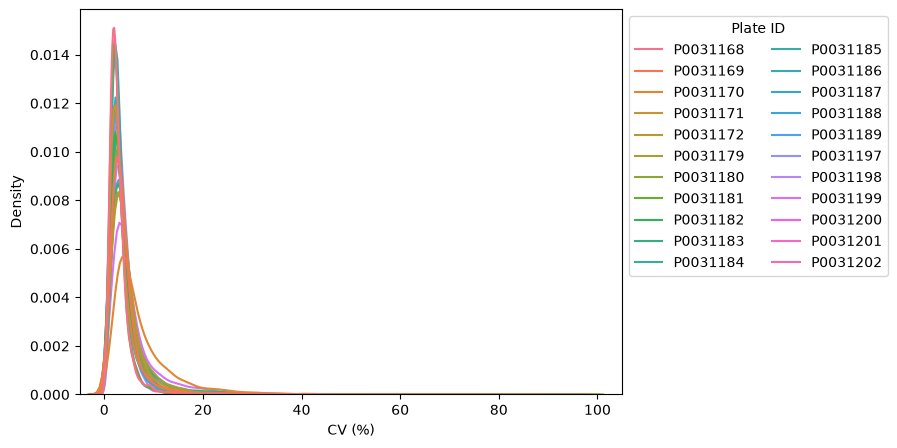

In [6]:
fig = plt.figure(figsize = [7, 5])

ax = sns.kdeplot(
    data=calibrator_cv_by_plate[calibrator_cv_by_plate.cv < 100],
    x="cv",
    hue="PlateId"
)

plt.xlabel("CV (%)")
handles = ax.get_legend().legend_handles
labels = [t.get_text() for t in ax.get_legend().get_texts()]
ax.legend(
    handles,
    labels,
    title="Plate ID",
    ncol=2,
    bbox_to_anchor=(1, 1),
    loc="upper left"
)
plt.xlim(-5, 105)

plt.show()

In [7]:
calibrator_measurements_deduplicated = (
    calibrator_measurements.sort_values(["PlateId", "PlatePosition"])
                           .drop_duplicates(["PlateId", "SeqId"])
)
calibrator_measurements_deduplicated

,PlateId,PlatePosition,SeqId,value
0,P0031168,A9,10000-28,893.2555
1,P0031168,A9,10001-7,403.4078
2,P0031168,A9,10003-15,227.4742
3,P0031168,A9,10006-25,841.5257
4,P0031168,A9,10008-43,743.2851
...,...,...,...,...
699643,P0031202,A9,9993-11,1709.2900
699644,P0031202,A9,9994-217,2076.2660
699645,P0031202,A9,9995-6,2370.9650
699646,P0031202,A9,9997-12,7409.7340


In [8]:
calibrator_cv_across_plates = (
    100 * calibrator_measurements_deduplicated.groupby("SeqId").value.std() / calibrator_measurements_deduplicated.groupby("SeqId").value.mean()
).rename("cv").to_frame().reset_index()
calibrator_cv_across_plates

,SeqId,cv
0,10000-28,1.649686
1,10001-7,1.824844
2,10003-15,5.187689
3,10006-25,1.746308
4,10008-43,1.527489
...,...,...
7283,9993-11,3.405568
7284,9994-217,1.591657
7285,9995-6,2.003880
7286,9997-12,4.045927


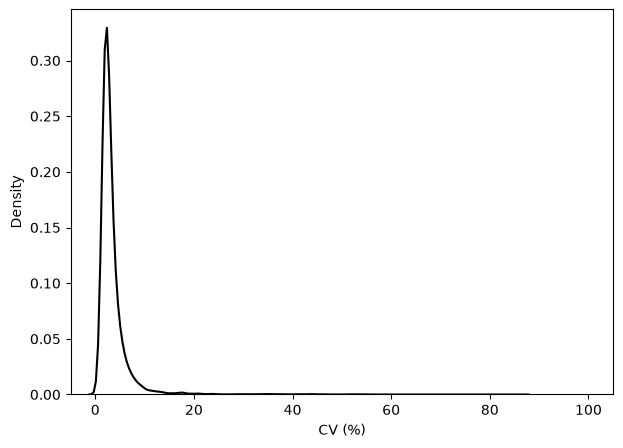

In [9]:
fig = plt.figure(figsize = [7, 5])

ax = sns.kdeplot(
    data=calibrator_cv_across_plates[calibrator_cv_across_plates.cv < 100],
    x="cv",
    c = "black"
)

plt.xlabel("CV (%)")
plt.xlim(-5, 105)
plt.show()

### Sample Dispersion

In [10]:
sample_measurements = (
    samples.loc[samples.SampleType == "Sample", ["PlateId", "PlatePosition"]]
           .merge(measurements)
           .merge(somamer.loc[np.logical_and(somamer.Organism == "Human", somamer.Type == "Protein"), "SeqId"])
)

<Axes: xlabel='Replication', ylabel='count'>

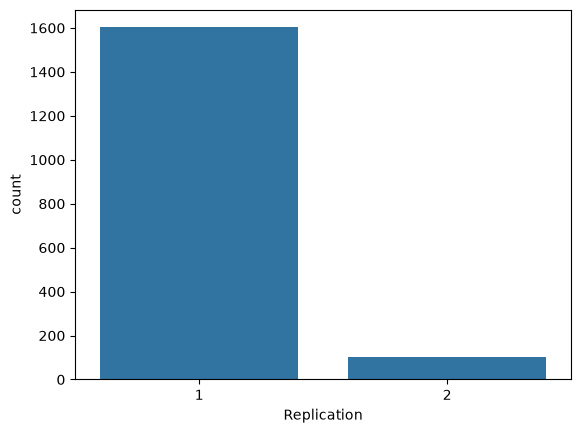

In [11]:
sns.barplot(
    data = (
        samples.loc[samples.SampleType == "Sample", :]
               .SampleId
               .value_counts()
               .rename("Replication")
               .value_counts()
               .to_frame()
    ),
    x = "Replication",
    y = "count"
)

In [12]:
replicated_samples = samples.loc[samples.SampleType == "Sample", :].SampleId.value_counts().to_frame().reset_index()
replicated_samples = replicated_samples[replicated_samples["count"] > 1]

In [13]:
replicated_samples

,SampleId,count
0,1073-17,2
1,1944-4,2
2,7889-2,2
3,6041-4,2
4,5283-13,2
...,...,...
97,4670-4,2
98,7930-4,2
99,5530-9,2
100,7500-1,2


In [14]:
nonreplicated_sample_measurements = sample_measurements.merge(
    replicated_samples.drop("count", axis = 1).merge(samples).loc[:, ["PlateId", "PlatePosition"]],
    how = "left_anti"
)
nonreplicated_sample_measurements["log2Value"] = np.log2(nonreplicated_sample_measurements["value"])

In [15]:
nonreplicated_sample_cv_by_plate = (
    100 * nonreplicated_sample_measurements.groupby(["PlateId", "SeqId"]).value.std() / nonreplicated_sample_measurements.groupby(["PlateId", "SeqId"]).value.mean()
).rename("cv").to_frame().reset_index()
nonreplicated_sample_cv_by_plate

,PlateId,SeqId,cv
0,P0031168,10000-28,409.978840
1,P0031168,10001-7,25.675626
2,P0031168,10003-15,150.244754
3,P0031168,10006-25,64.958374
4,P0031168,10008-43,34.588950
...,...,...,...
153043,P0031201,9993-11,9.893751
153044,P0031201,9994-217,36.164537
153045,P0031201,9995-6,58.456396
153046,P0031201,9997-12,54.002584


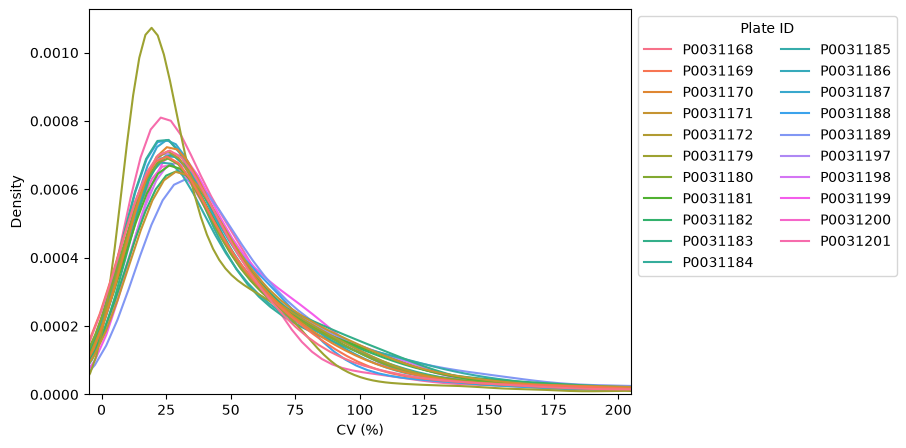

In [16]:
fig = plt.figure(figsize = [7, 5])

ax = sns.kdeplot(
    data=nonreplicated_sample_cv_by_plate,
    x="cv",
    hue="PlateId"
)

plt.xlabel("CV (%)")
handles = ax.get_legend().legend_handles
labels = [t.get_text() for t in ax.get_legend().get_texts()]
ax.legend(
    handles,
    labels,
    title="Plate ID",
    ncol=2,
    bbox_to_anchor=(1, 1),
    loc="upper left"
)
plt.xlim(-5, 205)

plt.show()

In [17]:
replicated_sample_measurements = sample_measurements.merge(
    replicated_samples.drop("count", axis = 1).merge(samples).loc[:, ["PlateId", "PlatePosition"]]
)
replicated_sample_measurements["log2Value"] = np.log2(replicated_sample_measurements["value"])

In [18]:
replicated_sample_measurements_diff = (
    replicated_sample_measurements.merge(
                                      samples.loc[:, ["PlateId", "PlatePosition", "SampleId"]]
                                  ).sort_values(["SampleId", "SeqId", "PlateId"])
                                  .groupby(["SampleId", "SeqId"])
                                  .log2Value
                                  .diff()
                                  .rename("log2ValueDiff")
                                  .to_frame()
)
replicated_sample_measurements_diff[["SampleId", "SeqId"]] = replicated_sample_measurements.merge(
  samples.loc[:, ["PlateId", "PlatePosition", "SampleId"]]
).sort_values(["SampleId", "SeqId", "PlateId"])[["SampleId", "SeqId"]]
replicated_sample_measurements_diff = replicated_sample_measurements_diff.dropna()

In [19]:
replicated_sample_measurements_diff.groupby("SeqId").log2ValueDiff.var()

SeqId
10000-28    0.006835
10001-7     0.007587
10003-15    0.104866
10006-25    0.005411
10008-43    0.003306
              ...   
9993-11     0.007525
9994-217    0.004100
9995-6      0.025179
9997-12     0.043030
9999-1      0.016361
Name: log2ValueDiff, Length: 7288, dtype: float64

In [20]:
random_matched_samples = nonreplicated_sample_measurements.loc[:, ["PlateId", "PlatePosition"]].drop_duplicates()
random_matched_samples = random_matched_samples.sample(random_matched_samples.shape[0], replace = False)
random_matched_samples["SampleId"] = np.repeat(np.arange(1, int(random_matched_samples.shape[0]/2) + 1), 2)
counts = random_matched_samples.drop_duplicates(["SampleId", "PlateId"]).SampleId.value_counts().reset_index()
random_matched_samples = random_matched_samples.merge(counts[counts["count"] == 2].head(replicated_samples.shape[0]))

In [21]:
nonreplicated_sample_measurements

,PlateId,PlatePosition,SeqId,value,log2Value
0,P0031168,A1,10000-28,799.4335,9.642834
1,P0031168,A1,10001-7,335.0557,8.388257
2,P0031168,A1,10003-15,221.4290,7.790700
3,P0031168,A1,10006-25,594.2082,9.214825
4,P0031168,A1,10008-43,746.0182,9.543067
...,...,...,...,...,...
13154835,P0031201,H8,9993-11,1142.1550,10.157543
13154836,P0031201,H8,9994-217,1480.9760,10.532333
13154837,P0031201,H8,9995-6,4750.0030,12.213713
13154838,P0031201,H8,9997-12,40241.0400,15.296380


In [22]:
random_matched_samples

,PlateId,PlatePosition,SampleId,count
0,P0031186,F7,1,2
1,P0031188,D6,1,2
2,P0031197,B1,2,2
3,P0031169,A12,2,2
4,P0031172,A5,3,2
...,...,...,...,...
199,P0031181,C6,107,2
200,P0031201,B5,108,2
201,P0031186,G7,108,2
202,P0031186,F8,110,2


In [23]:
nonreplicated_sample_measurements_diff = (
    nonreplicated_sample_measurements.merge(
                                      random_matched_samples.loc[:, ["PlateId", "PlatePosition", "SampleId"]]
                                  ).sort_values(["SampleId", "SeqId", "PlateId"])
                                  .groupby(["SampleId", "SeqId"])
                                  .log2Value
                                  .diff()
                                  .rename("log2ValueDiff")
                                  .to_frame()
)
nonreplicated_sample_measurements_diff[["SampleId", "SeqId"]] = nonreplicated_sample_measurements.merge(
  random_matched_samples.loc[:, ["PlateId", "PlatePosition", "SampleId"]]
).sort_values(["SampleId", "SeqId", "PlateId"])[["SampleId", "SeqId"]]
nonreplicated_sample_measurements_diff = nonreplicated_sample_measurements_diff.dropna()

In [24]:
nonreplicated_sample_measurements_diff

,log2ValueDiff,SampleId,SeqId
947440,0.034020,1,10000-28
947441,-0.046018,1,10001-7
947442,0.192381,1,10003-15
947443,0.235174,1,10006-25
947444,-0.114301,1,10008-43
...,...,...,...
991163,-0.436208,110,9993-11
991164,-0.238582,110,9994-217
991165,2.763706,110,9995-6
991166,2.632549,110,9997-12


In [25]:
nonreplicated_sample_measurements_diff.groupby("SeqId").log2ValueDiff.var()

SeqId
10000-28    0.710489
10001-7     0.634398
10003-15    0.509469
10006-25    0.114450
10008-43    0.123542
              ...   
9993-11     0.115829
9994-217    0.257236
9995-6      2.568519
9997-12     2.463826
9999-1      1.340554
Name: log2ValueDiff, Length: 7288, dtype: float64

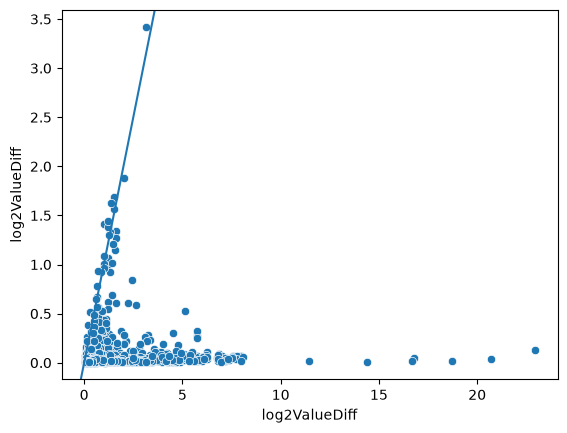

In [27]:
sns.scatterplot(
    x = nonreplicated_sample_measurements_diff.groupby("SeqId").log2ValueDiff.var(),
    y = replicated_sample_measurements_diff.groupby("SeqId").log2ValueDiff.var()
)

plt.axline(xy1 = [0, 0], slope = 1)

### Direct Assessment of Probe CV

In [31]:
from scipy.stats import norm
from scipy.optimize import minimize

In [136]:
replicated_sample_measurements_diff.groupby("SeqId").log2ValueDiff.var().sort_values().head(7000)

SeqId
22050-19    0.001408
19170-25    0.001489
21499-17    0.001491
12018-84    0.001734
25954-3     0.001778
              ...   
11265-8     0.086149
10582-36    0.086744
19483-16    0.087338
5864-10     0.087557
2682-68     0.088067
Name: log2ValueDiff, Length: 7000, dtype: float64

In [137]:
data = (
    (
        replicated_sample_measurements.merge(
                                          samples.loc[:, ["PlateId", "PlatePosition", "SampleId"]]
                                      ).sort_values(["SampleId", "SeqId", "PlateId"])
                                      .groupby(["SampleId", "SeqId"])
                                      .value
                                      .max()
    ) /
    (
        replicated_sample_measurements.merge(
                                          samples.loc[:, ["PlateId", "PlatePosition", "SampleId"]]
                                      ).sort_values(["SampleId", "SeqId", "PlateId"])
                                      .groupby(["SampleId", "SeqId"])
                                      .value
                                      .min()
    )
)
data = data.reset_index()
data = data[data.SeqId == "2682-68"].value.values
data

array([1.40737825, 1.07374125, 1.22616549, 1.13306796, 1.06463613,
       1.0711477 , 1.16804002, 1.01713476, 1.27242722, 1.19546102,
       1.13064962, 1.06425908, 1.02513137, 2.07097464, 1.17859795,
       1.59565528, 1.22037785, 1.23403418, 1.23956898, 1.1224804 ,
       1.11035931, 1.00966188, 1.06029272, 1.13677219, 1.04858597,
       1.01854623, 1.1986608 , 1.03501263, 1.00874314, 1.30866071,
       1.01778346, 1.12103262, 1.06103462, 1.09475802, 1.19264143,
       1.29888237, 1.09473382, 1.04036035, 1.1204382 , 1.06982402,
       1.48189658, 1.02235339, 1.4648928 , 1.06099839, 1.0143143 ,
       1.01166005, 1.05433977, 1.04650042, 1.11853306, 1.00705564,
       1.05330185, 1.04782232, 1.01554913, 1.06582798, 1.00637409,
       1.63273631, 1.08279234, 1.65769699, 1.0486808 , 1.42327559,
       1.18085569, 1.01809837, 1.86063785, 1.08406668, 1.05984523,
       1.10001008, 1.26106252, 1.51000189, 1.07926271, 1.13415871,
       1.31941884, 1.24922778, 1.14581201, 1.05096676, 1.39766

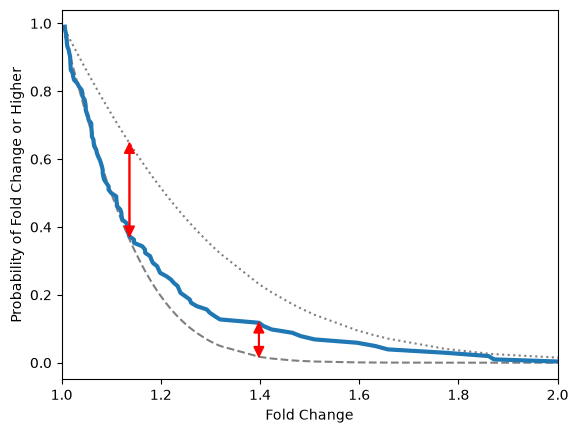

In [194]:
fc = np.sort(np.maximum(data, 1/data))

sns.lineplot(
    x = fc,
    y = np.arange(data_corrected.shape[0])[::-1]/data_corrected.shape[0],
    linewidth = 3,
    zorder = 1
)

den = np.sqrt(
    2*np.log(
        np.pow(20/100, 2) + 1
    )
)
prob = 2*norm.cdf(-1*np.log(fc)/den)
sns.lineplot(
    x = fc,
    y = prob,
    c = "black",
    linestyle = "dotted",
    alpha = .5,
    zorder = 0
)
diff = np.abs(
    prob -
        np.arange(data_corrected.shape[0])[::-1]/data_corrected.shape[0]
)
argmax = np.argmax(diff)
plt.arrow(
    x = fc[argmax], dx = 0,
    y = prob[argmax], dy = (np.arange(data_corrected.shape[0])[::-1]/data_corrected.shape[0])[argmax] - prob[argmax],
    head_width=0.02,
    head_length=0.03,
    linewidth=1,
    color='r',
    length_includes_head=True,
    zorder = 2
)
plt.arrow(
    x = fc[argmax], dx = 0,
    y = (np.arange(data_corrected.shape[0])[::-1]/data_corrected.shape[0])[argmax], dy = prob[argmax] - (np.arange(data_corrected.shape[0])[::-1]/data_corrected.shape[0])[argmax],
    head_width=0.02,
    head_length=0.03,
    linewidth=1,
    color='r',
    length_includes_head=True,
    zorder = 2
)

den = np.sqrt(
    2*np.log(
        np.pow(10/100, 2) + 1
    )
)
prob = 2*norm.cdf(-1*np.log(fc)/den)
sns.lineplot(
    x = fc,
    y = prob,
    c = "black",
    linestyle = "dashed",
    alpha = .5,
    zorder = 0
)
diff = np.abs(
    prob -
        np.arange(data_corrected.shape[0])[::-1]/data_corrected.shape[0]
)
argmax = np.argmax(diff)
plt.arrow(
    x = fc[argmax], dx = 0,
    y = prob[argmax], dy = (np.arange(data_corrected.shape[0])[::-1]/data_corrected.shape[0])[argmax] - prob[argmax],
    head_width=0.02,
    head_length=0.03,
    linewidth=1,
    color='r',
    length_includes_head=True,
    zorder = 2
)
plt.arrow(
    x = fc[argmax], dx = 0,
    y = (np.arange(data_corrected.shape[0])[::-1]/data_corrected.shape[0])[argmax], dy = prob[argmax] - (np.arange(data_corrected.shape[0])[::-1]/data_corrected.shape[0])[argmax],
    head_width=0.02,
    head_length=0.03,
    linewidth=1,
    color='r',
    length_includes_head=True,
    zorder = 2
)

plt.xlabel("Fold Change")
plt.ylabel("Probability of Fold Change or Higher")

plt.xlim(1, 2)
plt.show()

In [348]:
def fit(fc):
    fc = np.sort(fc)
    cvs = np.arange(1, 100)
    scores = np.zeros(cvs.shape[0])
    for i in range(len(cvs)):
        den = np.sqrt(
            2*np.log(
                np.pow(cvs[i]/100, 2) + 1
            )
        )
        prob = 2*norm.cdf(-1*np.log(fc)/den)
        diff = np.abs(
            prob -
                np.arange(fc.shape[0])[::-1]/fc.shape[0]
        )
        scores[i] = np.max(diff)

    return cvs, scores

fc = np.sort(np.maximum(data, 1/data))
cvs_ks, scores_ks = fit(fc)

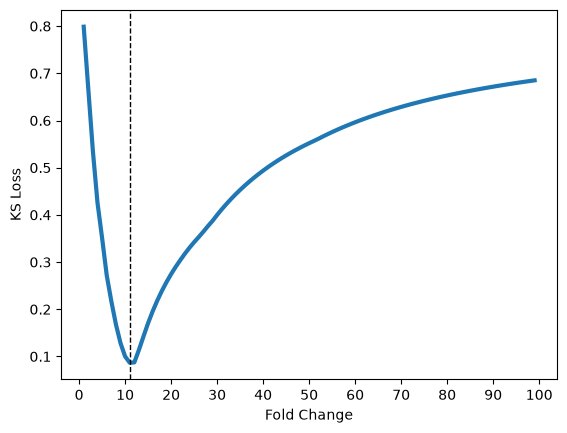

In [349]:
argmin_ks = np.argmin(scores_ks)

sns.lineplot(
    x = cvs_ks,
    y = scores_ks,
    linewidth = 3
)
plt.axvline(
    x = cvs_ks[argmin_ks],
    ymin = 0,
    ymax = 1,
    linewidth = 1,
    linestyle = "dashed",
    color = "black"
)

plt.xticks(range(0, 101, 10))
plt.xlabel("Fold Change")
plt.ylabel("KS Loss")

plt.show()

In [350]:
def factor_pdf(fold_change, cv):
    """PDF of the fold change Y/X (larger over smaller) for two i.i.d. log-normal measurements with percent CV."""
    fold_change = np.asarray(fold_change)
    theta = cv / 100
    x = np.abs(np.log(fold_change))
    log_term = np.log(theta**2 + 1)
    return 1.0 / np.sqrt(np.pi * log_term) * np.exp(-(x**2) / (4 * log_term))

def fit(fc):
    fc = np.sort(fc)
    cvs = np.arange(2, 100)
    scores = np.zeros(cvs.shape[0])
    for i in range(len(cvs)):
        scores[i] = -np.sum(
            np.log(
                factor_pdf(fc, cvs[i])
            )
        )

    return cvs, scores

fc = np.sort(np.maximum(data, 1/data))
cvs, scores_ml = fit(fc)
cvs_ml, scores_ml = cvs[scores_ml < 0], scores_ml[scores_ml < 0]

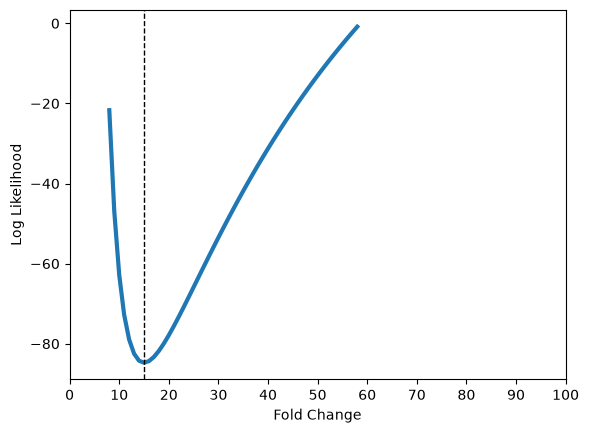

In [351]:
argmin_ml = np.argmin(scores_ml)

sns.lineplot(
    x = cvs_ml,
    y = scores_ml,
    linewidth = 3
)
plt.axvline(
    x = cvs_ml[argmin_ml],
    ymin = 0,
    ymax = 1,
    linewidth = 1,
    linestyle = "dashed",
    color = "black"
)

plt.xticks(range(0, 101, 10))
plt.xlabel("Fold Change")
plt.ylabel("Log Likelihood")

plt.show()

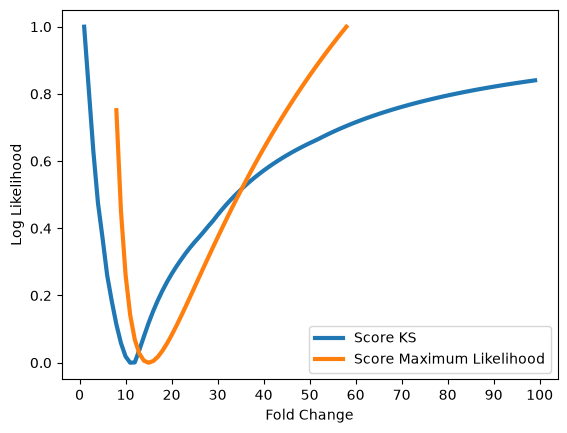

In [354]:
scores_ks = scores_ks - np.min(scores_ks)
scores_ks = scores_ks/np.max(scores_ks)
sns.lineplot(
    x = cvs_ks,
    y = scores_ks,
    linewidth = 3,
    label = "Score KS"
)

scores_ml = scores_ml - np.min(scores_ml)
scores_ml = scores_ml/np.max(scores_ml)
sns.lineplot(
    x = cvs_ml,
    y = scores_ml,
    linewidth = 3,
    label = "Score Maximum Likelihood"
)

plt.xticks(range(0, 101, 10))
plt.xlabel("Fold Change")
plt.ylabel("Log Likelihood")

plt.show()

In [356]:
def factor_mle(fold_change):
    """Maximum likelihood estimate of the percent CV from an array of fold changes (Y/X, larger over smaller)."""
    fold_change = np.asarray(fold_change)
    x = np.log(fold_change)
    theta = np.sqrt(np.exp(np.mean(x**2) / 2) - 1)
    return theta * 100

factor_mle(fc)

np.float64(14.993178130348934)